## PCA em 3D com classes químicas derivadas por SMARTS e os descritores selecionados

1. Faz importações
2. Configura variáveis (work features), caminhos (database e figuras), gráficos
3. Configura SMARTS e funções auxiliares
4. Prepara matriz de descritores e padroniza
5. Loadings, equações e PCA 3D

In [1]:
# =========================
# IMPORTAÇÕES
# =========================
import os
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# O toolkit RDKit é obrigatório para interpretar SMILES e aplicar SMARTS.
try:
    from rdkit import Chem
except ImportError as exc:
    raise ImportError(
        'O pacote RDKit não está instalado neste ambiente. Instale-o antes de executar este notebook.'
    ) from exc

In [2]:
# =========================
# CONFIGURAÇÕES GERAIS
# =========================
# Descritores numéricos usados na PCA. Eles entram na PCA; as classes NÃO entram.
WORK_FEATURES: List[str] = ['HOMO', 'GAP', 'CV', 'Enthalpy', 'DETmax'] #, 'CS']

# Coluna que contém a estrutura química.
SMILES_COLUMN: str = 'SMILES'

# Colunas candidatas para anotação no gráfico, se existirem no dataset.
LABEL_CANDIDATES: List[str] = [
    'Molecule', 'MoleculeName', 'Name', 'Compound', 'IUPACName', 'Synonym', 'classes'
]

# Caminho do arquivo de entrada. Altere aqui se necessário.
FILE_PATH = Path("../database/data/data_models_v1.xlsx")

# Diretório de saída para figuras e tabela de classificação SMARTS.
OUTPUT_DIR: Path = Path('outputs_pca_smarts_3d')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#FIGURES_DIR = Path(r"C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures")
#FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Controla se o gráfico exibirá rótulos dos centróides das classes.
ANNOTATE_CENTROIDS: bool = True

# Controla se o gráfico exibirá rótulos das moléculas. Útil apenas para datasets pequenos.
ANNOTATE_POINTS: bool = False

# Quantidade máxima de pontos a anotar, para evitar sobrecarga visual.
MAX_POINT_LABELS: int = 25

# Tamanho base dos pontos no gráfico 3D.
POINT_SIZE: int = 100

# Número mínimo de compostos para uma classe aparecer individualmente na legenda.
MIN_CLASS_SIZE_FOR_LEGEND: int = 6

print('Configurações carregadas.')
print(f'Arquivo de entrada atual: {FILE_PATH}')

Configurações carregadas.
Arquivo de entrada atual: ..\database\data\data_models_v1.xlsx


In [3]:
# =========================
# DEFINIÇÃO DOS SMARTS
# =========================
# Esta hierarquia foi copiada do script de treino e mantida na mesma ordem.
# No treino, a lógica era multirrótulo (one-hot); aqui, usamos a mesma hierarquia
# para definir uma única classe final por prioridade, preservando todos os matches.
HIERARQUIA_SMARTS: List[Tuple[str, str]] = [
    ('compostos nitro', '[N+](=O)[O-]'),
    ('sulfonamidas', '[#16H0](=[OX1])(=[OX1])-[#7]'),
    ('nitrilas', '[C]#[N]'),
    ('amidas', '[NX3][CX3](=[OX1])'),
    ('aminas', '[NX3;H2,H1,H0;!$(NC=O)]'),
    ('compostos halogenados', '[F,Cl,Br,I]'),
    ('heterociclos nitrogenados', '[n,N]1~[c,C,n,N]~[c,C,n,N]~[c,C,n,N]~[c,C,n,N]~1'),
    ('heterociclos oxigenados', '[o,O]1~[c,C,o,O]~[c,C,o,O]~[c,C,o,O]~[c,C,o,O]~1'),
    ('heterociclos sulfurados', '[s,S]1~[c,C,s,S]~[c,C,s,S]~[c,C,s,S]~[c,C,s,S]~1'),
    ('acetais', '[CX4](OC)(OC)'),
    ('anidridos de ácido', '[CX3](=[OX1])[OX2][CX3](=[OX1])'),
    ('ácidos carboxílicos', '[CX3](=O)[OX2H1]'),
    ('ésteres', '[CX3](=O)[OX2H0][#6]'),
    ('quinonas', '[#6]1(=O)[#6]=[#6][#6](=O)[#6]=[#6]1'),
    ('fenóis', '[OX2H]c1ccccc1'),
    ('epóxidos', '[C]1[O][C]1'),
    ('aldeídos', '[CX3H1](=O)'),
    ('cetonas', '[#6][CX3](=O)[#6]'),
    ('álcoois', '[OX2H][CX4]'),
    ('éteres', '[#6][OD2][#6]'),
    ('hidrocarbonetos aromáticos', 'c1ccccc1'),
    ('hidrocarbonetos insaturados', '[C]#[C]'),
    ('hidrocarbonetos insaturados', '[C]=[C]'),
]

print(f'Total de SMARTS na hierarquia: {len(HIERARQUIA_SMARTS)}')

Total de SMARTS na hierarquia: 23


In [4]:
# =========================
# FUNÇÕES AUXILIARES
# =========================
def compile_smarts_patterns(smarts_list: List[Tuple[str, str]]) -> List[Tuple[str, 'Chem.Mol']]:
    """Compila os SMARTS uma única vez para maior eficiência e validação prévia."""
    compiled_patterns: List[Tuple[str, 'Chem.Mol']] = []
    for class_name, smarts in smarts_list:
        pattern = Chem.MolFromSmarts(smarts)
        if pattern is None:
            print(f'[AVISO] SMARTS inválido ignorado: {class_name} -> {smarts}')
        else:
            compiled_patterns.append((class_name, pattern))
    return compiled_patterns

def load_dataset(file_path):
    """Carrega um dataset em CSV ou Excel, com mensagens de erro mais claras."""
    
    # Garante que o caminho seja tratado como objeto Path
    file_path = Path(file_path)

    # Verifica se o arquivo existe
    if not file_path.exists():
        raise FileNotFoundError(
            f"Arquivo não encontrado: {file_path}\n"
            f"Ajuste a variável FILE_PATH para o caminho correto do dataset."
        )

    # Identifica a extensão do arquivo de forma robusta
    suffix = file_path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(file_path)
    elif suffix in [".xlsx", ".xls"]:
        return pd.read_excel(file_path)
    else:
        raise ValueError(
            f"Formato de arquivo não suportado: {suffix}. "
            f"Use arquivos .csv, .xlsx ou .xls."
        )

def validate_required_columns(df: pd.DataFrame, required_columns: List[str]) -> None:
    """Valida a existência das colunas obrigatórias no dataframe."""
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        raise KeyError(
            'As seguintes colunas obrigatórias não foram encontradas no dataset: ' + ', '.join(missing_columns)
        )

def find_label_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    """Seleciona uma coluna útil para anotação, se houver alguma disponível."""
    for col in candidates:
        if col in df.columns:
            return col
    return None

def classify_molecule_smarts_cenario_a(smiles: str, compiled_patterns: List[Tuple[str, 'Chem.Mol']]) -> Dict[str, object]:
    """
    Classifica uma molécula seguindo o CENÁRIO A.

    Regras:
    1. A molécula pode casar com múltiplos SMARTS internamente.
    2. Todos os matches são registrados para rastreabilidade.
    3. A classe final única é definida pela PRIMEIRA classe encontrada na ordem da hierarquia SMARTS.
    4. Se não houver match SMARTS, testa-se 'hidrocarbonetos saturados'.
    5. Se nada casar, a classe final torna-se 'outros'.
    6. Se o SMILES for inválido, rotula como 'SMILES Inválido'.
    """
    result: Dict[str, object] = {
        'smiles_valido': False,
        'matches_multiplos': [],
        'classe_final': 'SMILES Inválido',
    }

    if pd.isna(smiles) or str(smiles).strip() == '':
        return result

    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return result

    result['smiles_valido'] = True
    matches: List[str] = []

    for class_name, pattern in compiled_patterns:
        if mol.HasSubstructMatch(pattern):
            matches.append(class_name)

    atom_symbols = {atom.GetSymbol() for atom in mol.GetAtoms()}
    if atom_symbols <= {'C', 'H'}:
        matches.append('hidrocarbonetos saturados')

    matches_unique = list(dict.fromkeys(matches))
    result['matches_multiplos'] = matches_unique

    if matches_unique:
        result['classe_final'] = matches_unique[0]
    else:
        result['classe_final'] = 'outros'

    return result

    # Cria um dicionário fixo classe -> cor, garantindo cor igual para classe igual."""
def build_class_color_map(class_names: List[str]) -> Dict[str, Tuple[float, float, float, float]]:
    cmap = plt.cm.get_cmap('tab20', max(len(class_names), 1))
    color_map: Dict[str, Tuple[float, float, float, float]] = {}
    for idx, class_name in enumerate(class_names):
        color_map[class_name] = cmap(idx)

    # Reserva explicitamente a cor cinza para o agrupamento "outros".
    if 'outros' in color_map:
        color_map['outros'] = (0.75, 0.75, 0.75, 0.9)

    # Garante que sulfonamidas não fique cinza, já que o cinza foi reservado para "outros".
    if 'sulfonamidas' in color_map:
        color_map['sulfonamidas'] = (0.55, 0.30, 0.75, 0.95)

    if 'SMILES Inválido' in color_map:
        color_map['SMILES Inválido'] = (0.2, 0.2, 0.2, 0.95)

    return color_map

# Agrupa em 'outros' as classes com menos de `min_size` compostos para simplificar a legenda
def group_small_classes_for_plot(df_pca: pd.DataFrame, min_size: int = 6, source_col: str = 'classe_final', target_col: str = 'classe_plot') -> pd.DataFrame:
    
    df_pca = df_pca.copy()

    # Conta quantos compostos existem em cada classe original derivada por SMARTS.
    class_counts = df_pca[source_col].value_counts(dropna=False)

    # Identifica apenas as classes que devem permanecer explícitas na legenda.
    classes_to_keep = class_counts[class_counts >= min_size].index.tolist()

    # Cria a coluna usada exclusivamente na visualização.
    df_pca[target_col] = df_pca[source_col].where(df_pca[source_col].isin(classes_to_keep), 'outros')

    return df_pca

def print_pca_results_to_terminal(df_pca: pd.DataFrame, label_col: Optional[str], explained_variance_ratio: np.ndarray, loadings_df: pd.DataFrame) -> None:
    """Imprime variância explicada, scores e loadings da PCA no terminal."""
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 220)
    pd.set_option('display.max_rows', 500)

    print('\n' + '=' * 90)
    print('VARIÂNCIA EXPLICADA PELA PCA (3 COMPONENTES)')
    print('=' * 90)
    for i, var in enumerate(explained_variance_ratio, start=1):
        print(f'PC{i}: {var:.6f} ({var * 100:.2f}%)')
    print(f'TOTAL: {explained_variance_ratio.sum():.6f} ({explained_variance_ratio.sum() * 100:.2f}%)')

    print('\n' + '=' * 90)
    print('SCORES DA PCA (PC1, PC2, PC3)')
    print('=' * 90)
    score_cols_to_show: List[str] = []
    if label_col is not None and label_col in df_pca.columns:
        score_cols_to_show.append(label_col)
    score_cols_to_show += [SMILES_COLUMN, 'classe_final', 'PC1', 'PC2', 'PC3']
    score_cols_to_show = list(dict.fromkeys(score_cols_to_show))
    scores_to_print = df_pca[score_cols_to_show].copy()
    scores_to_print[['PC1', 'PC2', 'PC3']] = scores_to_print[['PC1', 'PC2', 'PC3']].round(5)
    print(scores_to_print.to_string(index=False))

    print('\n' + '=' * 90)
    print('LOADINGS DA PCA')
    print('=' * 90)
    loadings_to_print = loadings_df.copy()
    loadings_to_print[['PC1', 'PC2', 'PC3']] = loadings_to_print[['PC1', 'PC2', 'PC3']].round(5)
    print(loadings_to_print.to_string(index=False))


    # Cria o gráfico 3D da PCA com cores por classe final usada na visualização."""

def create_3d_pca_plot(df_pca: pd.DataFrame, explained_variance_ratio: np.ndarray, label_col: Optional[str], color_map: Dict[str, Tuple[float, float, float, float]]) -> plt.Figure:

    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')

    # Usa a coluna de plotagem, se ela existir; caso contrário, usa a classe final original.
    plot_class_col = 'classe_plot' if 'classe_plot' in df_pca.columns else 'classe_final'

    class_order = list(color_map.keys())
    for class_name in class_order:
        subset = df_pca[df_pca[plot_class_col] == class_name].copy()
        if subset.empty:
            continue
        ax.scatter(
            subset['PC1'], subset['PC2'], subset['PC3'],
            s=POINT_SIZE, alpha=0.88, color=color_map[class_name],
            edgecolors='gray', linewidths=0.4,
            label=f'{class_name}')

#        if ANNOTATE_CENTROIDS:
#            centroid = subset[['PC1', 'PC2', 'PC3']].mean().values
#            ax.text(centroid[0], centroid[1], centroid[2], class_name, fontsize=9, fontweight='bold', color='black')

    if ANNOTATE_POINTS and label_col is not None and label_col in df_pca.columns:
        subset_for_labels = df_pca.head(MAX_POINT_LABELS)
        for _, row in subset_for_labels.iterrows():
            ax.text(row['PC1'], row['PC2'], row['PC3'], str(row[label_col]), fontsize=8, alpha=0.8)

    ax.set_xlabel(f'PC1 ({explained_variance_ratio[0] * 100:.2f}%)', fontsize=16, fontweight='bold', labelpad=14)
    ax.set_ylabel(f'PC2 ({explained_variance_ratio[1] * 100:.2f}%)', fontsize=16, fontweight='bold', labelpad=14)
    ax.set_zlabel(f'PC3 ({explained_variance_ratio[2] * 100:.2f}%)', fontsize=16, fontweight='bold', labelpad=14)
    # ax.set_title('PCA 3D do espaço químico com classes finais derivadas por SMARTS', fontsize=15, fontweight='bold', pad=20)

# Controla apenas o tamanho da fonte dos valores numéricos dos eixos

    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='z', labelsize=14)

   
    ax.plot([df_pca['PC1'].min(), df_pca['PC1'].max()], [0, 0], [0, 0], linestyle=':', linewidth=0.8, color='black', alpha=0.5)
    ax.plot([0, 0], [df_pca['PC2'].min(), df_pca['PC2'].max()], [0, 0], linestyle=':', linewidth=0.8, color='black', alpha=0.5)
    ax.plot([0, 0], [0, 0], [df_pca['PC3'].min(), df_pca['PC3'].max()], linestyle=':', linewidth=0.8, color='black', alpha=0.5)

    # Legenda: tamanho da fonte das classes + posição mais próxima do gráfico
    leg = ax.legend(title='Classes químicas', bbox_to_anchor=(1.06, 1.0), loc='upper left', frameon=True, fontsize=16, title_fontsize=16)

    # Deixa o título da legenda em negrito
    leg.get_title().set_fontweight('bold')
    
    fig.tight_layout()
    return fig

In [5]:
# =========================
# CARREGAMENTO E VALIDAÇÃO DO DATASET
# =========================
compiled_patterns = compile_smarts_patterns(HIERARQUIA_SMARTS)
print(f'Total de SMARTS compilados: {len(compiled_patterns)}')

df = load_dataset(FILE_PATH)
print(f'Dataset carregado com sucesso: {FILE_PATH}')
print(f'Número total de linhas: {len(df)}')

validate_required_columns(df, [SMILES_COLUMN] + WORK_FEATURES)
print('Colunas obrigatórias confirmadas.')

label_col = find_label_column(df, LABEL_CANDIDATES)
print(f'Coluna de anotação selecionada: {label_col}' if label_col else 'Nenhuma coluna de anotação encontrada.')

df.head()

Total de SMARTS compilados: 23
Dataset carregado com sucesso: ..\database\data\data_models_v1.xlsx
Número total de linhas: 152
Colunas obrigatórias confirmadas.
Coluna de anotação selecionada: classes


,Unnamed: 0,ID Sample,HeatOfCombustion,IUPACname,MM,FM,HOMO,LUMO,GAP,CV,...,CS,EI,e+,e-,Ne,DETmax,DEC,SMILES,LogHeatOfCombustion,classes
0,0,HXAE0128,4149.0,n-Hexane,86.11,C₆H₁₄,-0.36896,-0.02534,-0.34362,29.311,...,2.910191,0.113114,0.233165,0.036015,-0.197150,-1.147489,-0.113114,CCCCCC,8.330623,Hidrocarbonetos Saturados
1,1,HPTE0123,4756.2,n-Heptane,100.13,C₇H₁₆,-0.36379,-0.02589,-0.33790,34.094,...,2.959455,0.112349,0.230887,0.036047,-0.194840,-1.153241,-0.112349,CCCCCCC,8.467204,Hidrocarbonetos Saturados
2,2,TPTE0164,4804.0,"2,2,3-Trimethylbutane",100.13,C₇H₁₆,-0.36210,-0.02767,-0.33443,35.870,...,2.990162,0.113567,0.231911,0.037026,-0.194885,-1.165476,-0.113567,CC(C)C(C)(C)C,8.477204,Hidrocarbonetos Saturados
3,3,OTAE0049,5447.9,n-Octane,114.14,C₈H₁₈,-0.35977,-0.02629,-0.33348,38.947,...,2.998681,0.111733,0.229090,0.036060,-0.193030,-1.157671,-0.111733,CCCCCCCC,8.602985,Hidrocarbonetos Saturados
4,4,MLHE0136,5464.7,2-Methylheptane,114.14,C₈H₁₈,-0.35909,-0.02760,-0.33149,39.490,...,3.016682,0.112770,0.230161,0.036816,-0.193345,-1.166521,-0.112770,CCCCCC(C)C,8.606065,Hidrocarbonetos Saturados


In [6]:
# =========================
# CLASSIFICAÇÃO QUÍMICA POR SMARTS
# =========================
classification_results = df[SMILES_COLUMN].apply(
    lambda smiles: classify_molecule_smarts_cenario_a(smiles, compiled_patterns)
)
classification_df = pd.DataFrame(list(classification_results))

# Converte a lista de matches em string para facilitar leitura e exportação.
classification_df['matches_multiplos'] = classification_df['matches_multiplos'].apply(
    lambda matches: ' | '.join(matches) if matches else ''
)

# Integra a classificação ao dataframe principal.
df = pd.concat([df, classification_df], axis=1)

print(df['classe_final'].value_counts(dropna=False).to_string())

display_cols = [SMILES_COLUMN, 'smiles_valido', 'matches_multiplos', 'classe_final']
if label_col is not None and label_col in df.columns:
    display_cols = [label_col] + display_cols

df[display_cols].head(15)

classe_final
fenóis                         16
álcoois                        15
acetais                        13
ácidos carboxílicos            13
ésteres                        13
heterociclos oxigenados        12
hidrocarbonetos saturados      11
cetonas                        10
aldeídos                        9
éteres                          8
hidrocarbonetos aromáticos      7
sulfonamidas                    6
hidrocarbonetos insaturados     6
anidridos de ácido              6
quinonas                        3
epóxidos                        2
compostos halogenados           1
compostos nitro                 1


,classes,SMILES,smiles_valido,matches_multiplos,classe_final
0,Hidrocarbonetos Saturados,CCCCCC,True,hidrocarbonetos saturados,hidrocarbonetos saturados
1,Hidrocarbonetos Saturados,CCCCCCC,True,hidrocarbonetos saturados,hidrocarbonetos saturados
2,Hidrocarbonetos Saturados,CC(C)C(C)(C)C,True,hidrocarbonetos saturados,hidrocarbonetos saturados
3,Hidrocarbonetos Saturados,CCCCCCCC,True,hidrocarbonetos saturados,hidrocarbonetos saturados
4,Hidrocarbonetos Saturados,CCCCCC(C)C,True,hidrocarbonetos saturados,hidrocarbonetos saturados
5,Hidrocarbonetos Saturados,CCCCCCCCCC,True,hidrocarbonetos saturados,hidrocarbonetos saturados
6,Hidrocarbonetos Saturados,CCCCCCCCCCCCCCCC,True,hidrocarbonetos saturados,hidrocarbonetos saturados
7,Hidrocarbonetos Saturados,C1CCCC1,True,hidrocarbonetos saturados,hidrocarbonetos saturados
8,Hidrocarbonetos Saturados,C1CCCCC1,True,hidrocarbonetos saturados,hidrocarbonetos saturados
9,Cetonas E Compostos Carbonílicos,C1CCCC(=O)CC1,True,cetonas,cetonas


In [7]:
# =========================
# PREPARO DA MATRIZ DE DESCRITORES E PADRONIZAÇÃO
# =========================
# Remove apenas linhas sem descritores numéricos para a PCA.
df_pca = df.dropna(subset=WORK_FEATURES).copy()
removed_rows = len(df) - len(df_pca)
if removed_rows > 0:
    print(f'[AVISO] {removed_rows} linha(s) removida(s) da PCA por falta de descritores numéricos.')

# Monta a matriz de entrada da PCA APENAS com descritores numéricos.
X = df_pca[WORK_FEATURES].values

# Padroniza os descritores para evitar dominância por escala.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Dimensões da matriz original: {X.shape}')
print(f'Dimensões da matriz padronizada: {X_scaled.shape}')
pd.DataFrame(X_scaled, columns=WORK_FEATURES).head()

Dimensões da matriz original: (152, 5)
Dimensões da matriz padronizada: (152, 5)


,HOMO,GAP,CV,Enthalpy,DETmax
0,-1.472706,-1.590356,-0.700517,0.736792,0.815942
1,-1.312236,-1.449807,-0.486401,0.662062,0.790101
2,-1.259781,-1.364544,-0.406897,0.662039,0.735134
3,-1.187460,-1.341201,-0.269152,0.587333,0.770198
4,-1.166354,-1.292304,-0.244844,0.587326,0.730438


In [8]:
# =========================
# PCA 3D
# =========================

# Cria o objeto PCA com 3 componentes principais
pca = PCA(n_components=3)

# Ajusta a PCA aos dados padronizados e obtém as coordenadas
coords = pca.fit_transform(X_scaled)

# Adiciona os scores das três componentes principais ao dataframe final
df_pca['PC1'] = coords[:, 0]
df_pca['PC2'] = coords[:, 1]
df_pca['PC3'] = coords[:, 2]

# Captura a variância explicada por cada componente
explained_variance_ratio = pca.explained_variance_ratio_

# Organiza a variância explicada em formato tabular
explained_variance_df = pd.DataFrame({
    'Componente': ['PC1', 'PC2', 'PC3'],
    'Variancia_Explicada': explained_variance_ratio,
    'Percentual': explained_variance_ratio * 100,
})

explained_variance_df

,Componente,Variancia_Explicada,Percentual
0,PC1,0.576619,57.661878
1,PC2,0.230414,23.041407
2,PC3,0.146181,14.618051


In [9]:
# =========================
# LOADINGS DA PCA
# =========================
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=WORK_FEATURES,
    columns=['PC1', 'PC2', 'PC3'],
).reset_index().rename(columns={'index': 'Descritor'})

loadings_df

,Descritor,PC1,PC2,PC3
0,HOMO,0.401710,0.559887,0.480993
1,GAP,0.529086,0.401142,-0.091567
2,CV,0.415986,-0.496033,0.408045
3,Enthalpy,-0.438432,0.528732,-0.053733
4,DETmax,-0.439807,-0.002285,0.768683


### Heatmap de loadings (PC1, PC2 e PC3)

#✅ Matriz de Loadings 3D salva com sucesso em:C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures


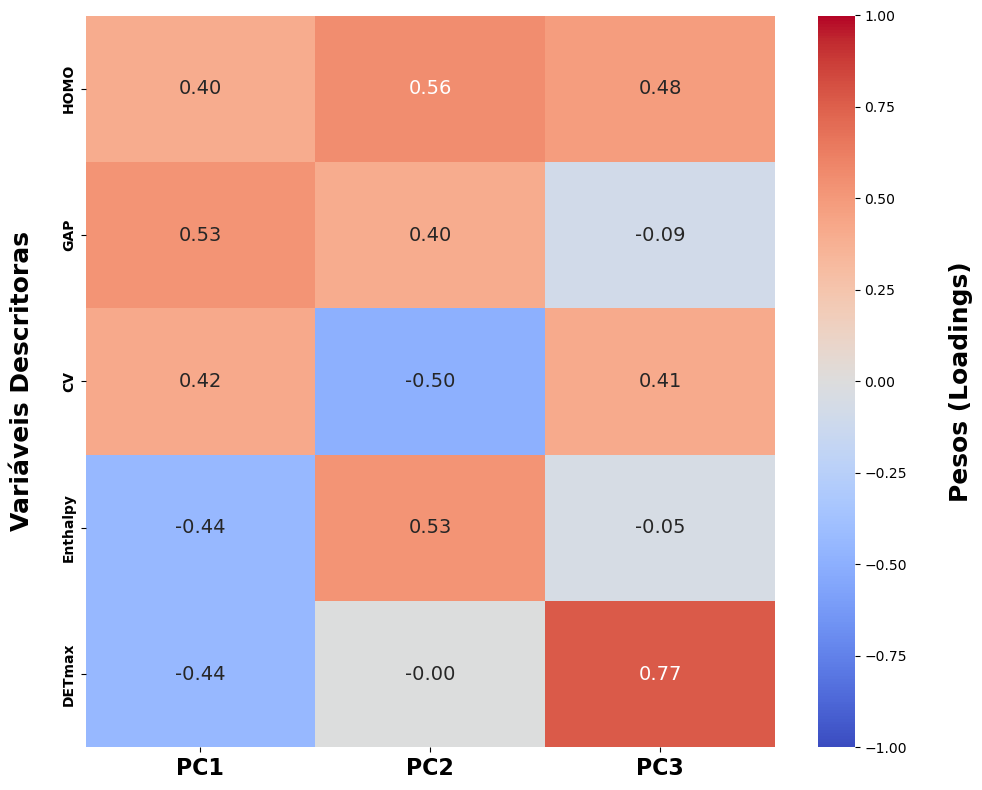

Interpretação:
-> Valores próximos de +1 ou -1 indicam forte influência.
-> Valores próximos de 0 indicam que a variável pouco contribui para aquele eixo.


In [10]:
# =========================
# HEATMAP DE LOADINGS (PC1, PC2 E PC3)
# =========================
import seaborn as sns

# 1. Extrai os pesos (loadings) da PCA já ajustada.
#    Cada linha representa um descritor e cada coluna representa uma componente principal.
loadings_heatmap = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3'],
    index=WORK_FEATURES
)

# 2. Cria a figura que receberá o heatmap.
fig_load, ax_load = plt.subplots(figsize=(10, 8))

# 3. Plota o heatmap com os valores anotados em cada célula.
#    O centro em zero ajuda a visualizar pesos positivos e negativos com mais clareza.
ax = sns.heatmap(
    loadings_heatmap,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    vmin=-1,
    vmax=1,
    annot_kws={"size": 14},
    ax=ax_load
)
# aumenta tamanho de PC1, PC2  e PC3 no eixo x
ax_load.tick_params(axis='x', labelsize=16)

# 4. Ajusta os elementos visuais do gráfico para manter o mesmo padrão do script 8.
ax.collections[0].colorbar.set_label('Pesos (Loadings)', fontweight='bold', labelpad=30, fontsize=18)
ax.set_ylabel('Variáveis Descritoras', fontsize=18, fontweight='bold', labelpad=20)
#ax.set_xlabel('Componentes Principais', fontsize=22, fontweight='bold', labelpad=15)
ax.set_xticklabels(ax.get_xticklabels(), fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), fontweight='bold')

# 5. Define o nome do arquivo e o diretório de exportação.
#name_arq = 'PCA_Loadings_Heatmap_3D'
#caminho = FIGURES_DIR

# 6. Salva a figura em PNG de alta resolução.
#caminho_png = os.path.join(caminho, name_arq + '.png')
#fig_load.savefig(caminho_png, dpi=600, bbox_inches='tight', facecolor='white')

# 7. Salva também em SVG para edição vetorial sem perda de qualidade.
#caminho_svg = os.path.join(caminho, name_arq + '.svg')
#fig_load.savefig(caminho_svg, format='svg', bbox_inches='tight', facecolor='white')
#print(f'✅ Matriz de Loadings 3D salva com sucesso em:{caminho}')

# 8. Organiza o layout final e exibe a figura.
plt.tight_layout()
plt.show()

# 9. Mensagens curtas para orientar a interpretação dos pesos.
print('Interpretação:')
print('-> Valores próximos de +1 ou -1 indicam forte influência.')
print('-> Valores próximos de 0 indicam que a variável pouco contribui para aquele eixo.')


### Equações lineares das componentes principais

In [11]:
# =========================
# EQUAÇÕES DE PC1, PC2 E PC3
# =========================
# 1. Garante a ordem dos descritores exatamente como usada na PCA.
cols = list(WORK_FEATURES)

# 2. Reconstrói a tabela de loadings no formato descritor x componente.
#    Aqui cada coeficiente mostra quanto o descritor padronizado contribui para cada PC.
loadings_eq = pd.DataFrame(
    pca.components_.T,
    index=cols,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

# 3. Define uma função para montar a equação linear de cada componente principal.
#    A equação é escrita em termos das variáveis padronizadas z[descritor].
def eq_padronizada(k, top=None):
    s = loadings_eq.iloc[:, k].copy()

    # Se desejar, é possível limitar a impressão aos maiores coeficientes em módulo.
    if top:
        s = s.reindex(s.abs().sort_values(ascending=False).index).head(top)

    # Monta cada termo da combinação linear com sinal explícito.
    termos = [f'({coef:+.6f})*z[{name}]' for name, coef in s.items()]

    # Corrige a aparência do texto final, evitando sequências como '+ -'.
    return ' '.join(termos).replace('+ -', '- ')

# 4. Imprime as equações completas das três componentes principais.
print('PC1 (padronizada):')
print('PC1 =', eq_padronizada(0, top=30))

print('\nPC2 (padronizada):')
print('PC2 =', eq_padronizada(1, top=30))

print('\nPC3 (padronizada):')
print('PC3 =', eq_padronizada(2, top=30))


PC1 (padronizada):
PC1 = (+0.529086)*z[GAP] (-0.439807)*z[DETmax] (-0.438432)*z[Enthalpy] (+0.415986)*z[CV] (+0.401710)*z[HOMO]

PC2 (padronizada):
PC2 = (+0.559887)*z[HOMO] (+0.528732)*z[Enthalpy] (-0.496033)*z[CV] (+0.401142)*z[GAP] (-0.002285)*z[DETmax]

PC3 (padronizada):
PC3 = (+0.768683)*z[DETmax] (+0.480993)*z[HOMO] (+0.408045)*z[CV] (-0.091567)*z[GAP] (-0.053733)*z[Enthalpy]


In [12]:
# =========================
# IMPRESSÃO DOS RESULTADOS NO TERMINAL
# =========================
print_pca_results_to_terminal(df_pca, label_col, explained_variance_ratio, loadings_df)


VARIÂNCIA EXPLICADA PELA PCA (3 COMPONENTES)
PC1: 0.576619 (57.66%)
PC2: 0.230414 (23.04%)
PC3: 0.146181 (14.62%)
TOTAL: 0.953213 (95.32%)

SCORES DA PCA (PC1, PC2, PC3)
                         classes                                                                                                                                             SMILES                classe_final      PC1      PC2      PC3
       Hidrocarbonetos Saturados                                                                                                                                             CCCCCC   hidrocarbonetos saturados -2.40633 -0.72733 -0.26097
       Hidrocarbonetos Saturados                                                                                                                                            CCCCCCC   hidrocarbonetos saturados -2.13431 -0.72676 -0.12513
       Hidrocarbonetos Saturados                                                                                            

C:\Users\User\AppData\Local\Temp\ipykernel_11980\63872705.py:104: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(len(class_names), 1))


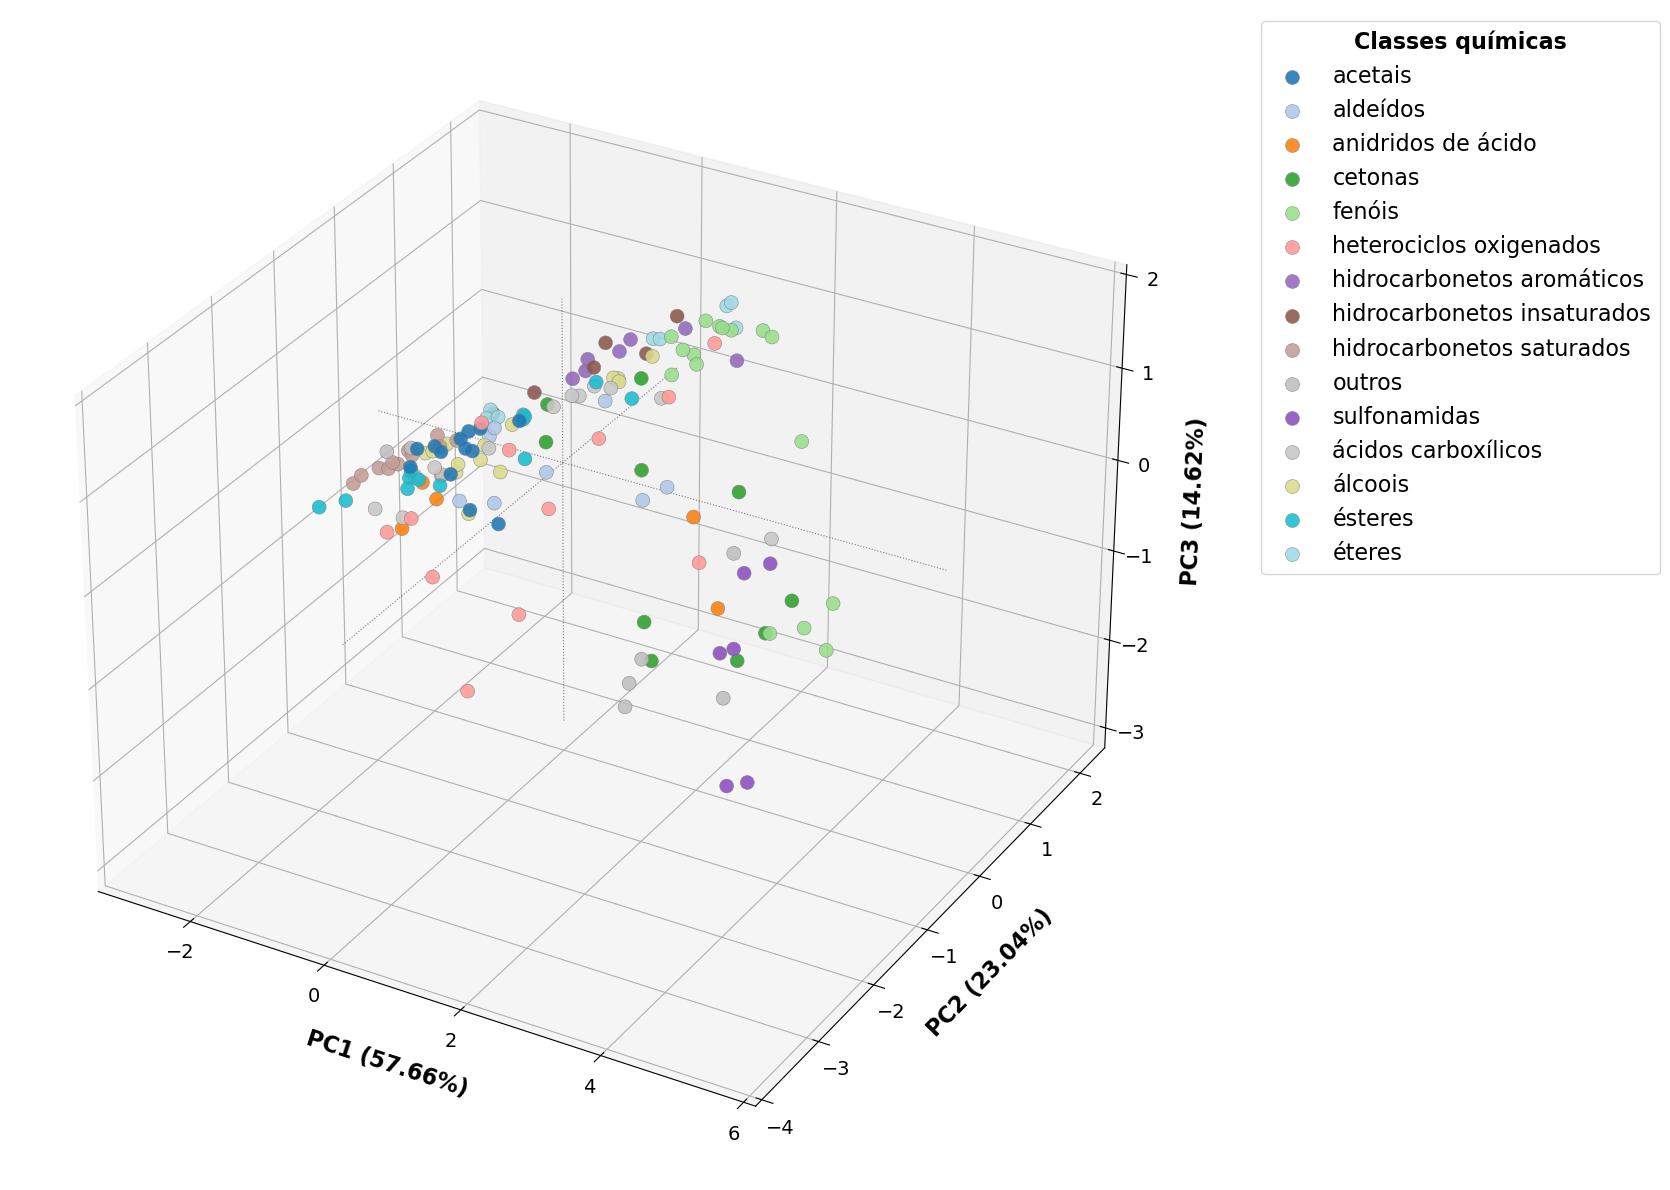

In [13]:
# =========================
# VISUALIZAÇÃO 3D
# =========================

# Agrupa em "outros" todas as classes com menos de 6 compostos,
# para que apenas as classes mais representativas apareçam explicitamente na legenda.
df_pca = group_small_classes_for_plot(
    df_pca=df_pca,
    min_size=MIN_CLASS_SIZE_FOR_LEGEND,
    source_col='classe_final',
    target_col='classe_plot',
)

# A ordem e as cores agora são construídas com base na coluna usada no gráfico.
class_order = sorted(df_pca['classe_plot'].dropna().unique().tolist())
color_map = build_class_color_map(class_order)

fig = create_3d_pca_plot(df_pca, explained_variance_ratio, label_col, color_map)
plt.show()


In [14]:
# =========================
# EXPORTAÇÕES FINAIS
# =========================

# Exporta apenas a tabela de classificação SMARTS no diretório atual
classification_cols = [SMILES_COLUMN, "smiles_valido", "matches_multiplos", "classe_final"]
if label_col is not None and label_col in df_pca.columns:
    classification_cols = [label_col] + classification_cols

df_pca[classification_cols].to_csv(
    OUTPUT_DIR / "smarts_classificacao_final.csv",
    index=False,
    encoding="utf-8-sig"
)

# Exporta as figuras no diretório específico de figuras
#fig.savefig(FIGURES_DIR / "pca_3d_smarts.png", dpi=300, bbox_inches="tight")
#fig.savefig(FIGURES_DIR / "pca_3d_smarts.svg", bbox_inches="tight")

print("\nArquivos exportados com sucesso:")
print(f"- {OUTPUT_DIR / 'smarts_classificacao_final.csv'}")
#print(f"- {FIGURES_DIR / 'pca_3d_smarts.png'}")
#print(f"- {FIGURES_DIR / 'pca_3d_smarts.svg'}")


Arquivos exportados com sucesso:
- outputs_pca_smarts_3d\smarts_classificacao_final.csv
#- C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures\pca_3d_smarts.png
#- C:\Users\User\OneDrive\Alex_CaloV_DFT\Dissertation\Figures\pca_3d_smarts.svg
